In [19]:
import sys
sys.path.append(r'/raven/u/nkerschb/project/ag-kepesidis/in-silico-infrared-modeling')

import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
import optuna

from optuna.visualization.matplotlib import *
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [20]:
from utils.utils import load_config

search_space = load_config("../cdiff_hyperparameterspace_full.yaml")
study_name = search_space.get("optuna", {}).get("version")

In [25]:
study = optuna.load_study(
    study_name=study_name,
    storage=f"sqlite:////raven/u/nkerschb/project/ag-kepesidis/in-silico-infrared-modeling/optuna_logs/{study_name}.db",
)

In [26]:
print("Loaded study:", study.study_name)
print("Best value:", study.best_value)
print("Best params:", study.best_params)

Loaded study: initial_search
Best value: 0.018903518095612526
Best params: {'cdiff.model_type': 'ResMLP', 'cdiff.hidden_dim': 940, 'cdiff.pos_embedding_dim': 12, 'cdiff.timestep_embedding_dim': 56, 'cdiff.n_layer': 2, 'cdiff.n_timesteps': 188, 'cdiff.p_uncond': 0.2676024359415444, 'cdiff.activation': 'silu', 'cdiff.ema_decay': 0.99, 'cdiff.timestep_truncation': 4, 'cdiff.learning_rate': 0.00021366690746342292, 'cdiff.weight_decay': 0.0002230308887766187, 'data.batch_size': 209}


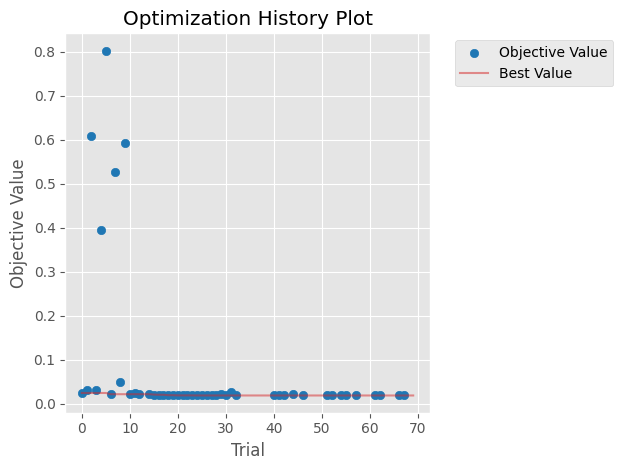

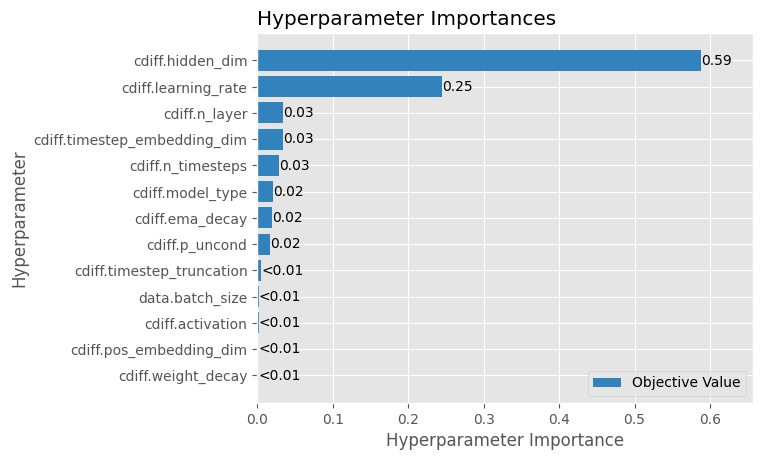

In [27]:
fig1 = plot_optimization_history(study)
plt.show()

fig2 = plot_param_importances(study)
plt.show()

In [28]:
# All trials as a DataFrame — useful for analysis
df = study.trials_dataframe()
df.sort_values("value")

,number,value,datetime_start,datetime_complete,duration,params_cdiff.activation,params_cdiff.ema_decay,params_cdiff.hidden_dim,params_cdiff.learning_rate,params_cdiff.model_type,params_cdiff.n_layer,params_cdiff.n_timesteps,params_cdiff.p_uncond,params_cdiff.pos_embedding_dim,params_cdiff.timestep_embedding_dim,params_cdiff.timestep_truncation,params_cdiff.weight_decay,params_data.batch_size,state
46,46,0.018904,2026-03-20 03:23:48.553247,2026-03-20 03:51:09.243477,0 days 00:27:20.690230,silu,0.990,940,0.000214,ResMLP,2,188,0.267602,12,56,4,0.000223,209,COMPLETE
26,26,0.018909,2026-03-19 20:24:27.552805,2026-03-19 21:11:50.540840,0 days 00:47:22.988035,silu,0.000,785,0.001921,ResMLP,3,185,0.266100,7,62,4,0.000803,130,COMPLETE
24,24,0.018934,2026-03-19 19:32:19.532338,2026-03-19 20:01:22.957303,0 days 00:29:03.424965,silu,0.000,772,0.000479,ResMLP,3,246,0.250379,11,63,2,0.001019,162,COMPLETE
30,30,0.018953,2026-03-19 22:54:12.906785,2026-03-19 23:39:45.542273,0 days 00:45:32.635488,silu,0.990,647,0.000124,ResMLP,2,142,0.122671,13,61,3,0.001014,199,COMPLETE
57,57,0.018961,2026-03-20 06:16:45.629692,2026-03-20 06:50:22.629111,0 days 00:33:36.999419,silu,0.990,865,0.000335,FiLMResMLP,5,219,0.240794,16,58,2,0.004396,194,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,2,0.607461,2026-03-17 10:57:41.020833,2026-03-17 11:03:00.312885,0 days 00:05:19.292052,elu,0.990,304,0.003111,MLP,8,165,0.233592,16,59,11,0.000200,218,COMPLETE
5,5,0.802307,2026-03-17 11:49:56.747215,2026-03-17 11:54:58.967129,0 days 00:05:02.219914,elu,0.999,558,0.005603,MLP,8,68,0.277579,4,13,9,0.000256,187,COMPLETE
64,64,0.837183,2026-03-20 08:18:05.917845,2026-03-20 08:26:20.022242,0 days 00:08:14.104397,silu,0.990,868,0.008656,ResMLP,8,223,0.246621,28,61,3,0.006018,206,PRUNED
13,13,NaN,2026-03-17 14:55:15.452737,NaT,NaT,silu,0.900,1022,0.000073,FiLMResMLP,6,54,0.214208,25,31,2,0.000379,33,RUNNING
